# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [78]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? - Indica qué harías: ¿imputar, eliminar, ignorar?
   En el datasets users hay dos columnas con valores nulos: city con 469 y churn_date con 3534 con una proporcion del 11,7% (0.11725) y 88% (0.88350) respectivamente. Con respecto a la acción la columna city se debe invertigar si se debe imputar o dejar como nulos, pero con la columna churn_date es necesario ignorarla o eliminarla por su alta cantidad de nulos.

  Con el otro datasets de usage, se presentan valores nulos en las columnas: date, duration y length con un valor de 50, 22076, 17896 respectivamente; con una proporcion de 0.1%(0.00125), 55% (0.55190) y 44% (0.44740). Con la columna date no es relevante sus valores nulos por tanto es necesario imputar o dejar como nulo, con las otras dos columnas que presentan el 55% y 44% es pertinente investigar para imputar o dejar como nulo.
  


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
columnas=["user_id","age"]
for col in columnas:
    print(col)
    print(users[col].unique())
    print()

users["age"].isin([-999]).sum()

user_id
[10000 10001 10002 ... 13997 13998 13999]

age
[  38   53   57   69   63   61   39   70   76   47   67   60 -999   78
   77   25   51   74   64   26   68   37   42   36   22   28   32   40
   44   49   43   79   59   46   56   58   50   54   33   24   29   45
   66   30   35   65   18   55   19   23   41   27   34   72   75   31
   71   52   20   73   21   62   48]



55

- La columna `user_id` presenta valores validos y unicos
- La columna `age` presenta valores validos a excepcion del -999 que aparece en 55 ocasiones.

In [13]:
# explorar columnas numéricas de usage
columnas_usage=["id","user_id","duration","length"]
for col in columnas_usage:
    print (col)
    print (usage[col].unique())
    print()

usage[["duration","length"]].isna().sum()

id
[    1     2     3 ... 39998 39999 40000]

user_id
[10332 11458 11777 ... 10278 12723 13883]

duration
[ 0.09   nan  1.53 ... 22.88 31.29 21.12]

length
[     nan 3.90e+01 3.60e+01 4.40e+01 7.00e+01 3.10e+01 8.50e+01 4.80e+01
 2.80e+01 5.90e+01 5.00e+01 5.20e+01 6.50e+01 4.70e+01 7.20e+01 3.70e+01
 6.60e+01 5.30e+01 2.40e+01 6.40e+01 5.40e+01 1.04e+02 4.20e+01 4.90e+01
 4.50e+01 2.60e+01 4.30e+01 2.10e+01 7.40e+01 5.80e+01 8.60e+01 2.90e+01
 7.30e+01 7.80e+01 3.50e+01 4.00e+01 5.60e+01 6.70e+01 9.40e+01 4.10e+01
 3.20e+01 5.70e+01 7.00e+00 7.60e+01 5.50e+01 2.70e+01 3.40e+01 3.30e+01
 5.10e+01 6.20e+01 6.00e+01 7.10e+01 9.10e+01 1.40e+01 3.80e+01 1.50e+01
 8.70e+01 1.70e+01 1.03e+02 4.60e+01 7.50e+01 0.00e+00 8.00e+01 1.10e+01
 6.90e+01 6.80e+01 6.30e+01 6.10e+01 1.80e+01 3.00e+00 2.30e+01 2.00e+01
 9.70e+01 9.00e+00 7.70e+01 8.10e+01 1.00e+01 9.80e+01 9.60e+01 1.90e+01
 4.00e+00 8.40e+01 8.30e+01 1.01e+02 3.00e+01 1.60e+01 5.00e+00 2.20e+01
 1.20e+01 1.02e+02 9.00e+01 8.80e+01 8.00

duration    22076
length      17896
dtype: int64

- Las columnas `id` y `user_id`presentan valores validos y unicos 
- Las columnas "duration" y "length" presentan valores nulos 

In [14]:
# explorar columnas categóricas de users
columnas_users = ['city', 'plan','first_name','last_name','reg_date','churn_date']
for col in columnas_users:
    print (col)
    print (users[col].value_counts())
    print()

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64

first_name
Mateo      685
Carlos     685
Ana        683
Mariana    661
Luis       645
Sofia      641
Name: first_name, dtype: int64

last_name
Lopez      835
Garcia     815
Torres     794
Ramirez    778
Gomez      778
Name: last_name, dtype: int64

reg_date
2026-05-10 00:00:00.000000000    40
2024-04-04 17:47:18.409602408     1
2022-05-06 16:23:02.745686422     1
2024-04-13 12:04:51.672918232     1
2024-08-19 09:02:17.734433616     1
                                 ..
2022-03-08 12:54:33.218304576     1
2023-01-17 03:43:36.954238560     1
2024-08-28 16:28:26.826706688     1
2023-07-31 15:52:47.891973000     1
2024-10-08 05:04:38.169542384     1
Name: reg_date, Length: 3961, dtype: int64

churn_date
1,72238E+18    6
1,71841E+18    6
1,71763E+18    6
1,72584E+18    5
1,73172E+18    5


- La columna `city` presenta un valor invalido "?" con una cantidad de 96 (65+31)
- La columna `plan` presenta los valores validos con todo completo 

In [15]:
# explorar columna categórica de usage
columnas_usage_categoricas=["type","date"]
for col in columnas_usage_categoricas:
    print(col)
    print(usage[col].value_counts())
    print()
print(usage["date"].isna().sum())# completa el código

type
text    22092
call    17908
Name: type, dtype: int64

date
2024-02-23 14:10:55.036375909    1
2024-06-08 17:40:33.030825770    1
2024-05-15 15:41:31.892297306    1
2024-06-16 03:53:34.430360758    1
2024-04-24 21:05:49.658741468    1
                                ..
2024-03-16 17:01:55.292882322    1
2024-02-20 07:07:09.040726018    1
2024-04-21 03:43:01.534538362    1
2024-01-25 15:00:57.511437785    1
2024-03-05 18:12:48.439210980    1
Name: date, Length: 39950, dtype: int64

50


- La columna `type` tiene dos textos que es text y call sin valores invalidos
- date tiene 50 valores vacios 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  Se encontraron valores invalidos en el datasets users en las columnas age con -999 y en la columna categorica city "?"
  Desde el datasets usage las columnas numericas duration y lenght tienes valores faltantes 
- ¿Qué acción tomarías?
  Desde la columna age del datasets users es necesario imputar con la mediana, al igual que las columnas duration y lenght, mientras que las categoricas como city se reemplazara por unknown
  y con respecto a la columna churn_date que tiene el 88% de faltantes es necesario mirar si no es al azar.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce") # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors="coerce") # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print (users["reg_date"].dt.year.unique())
print ((users["reg_date"].dt.year==2026).sum())


[2022 2026 2023 2024]
40


En `reg_date`, aparecen años unicos 2022,2026,2023,2024, por ende, aparece un año que seria imposible como es el caso de 2026 puesto que la investigacion es hasta el año 2024 y hay 40 veces en los datos

In [19]:
# Revisar los años presentes en `date` de usage
print (usage["date"].dt.year.unique())


[2024.   nan]


En `date`, podemos observar el año 2024 y un dato vacio que ya lo habiamos analizado arriba
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Existe año que es imposible puesto que esta aun sin transcurrir en el momentos de gaurdar los datos 
- ¿Qué harías con ellas?
  se pueden marcar como NaN para no perder toda la informacion relevante que puede haber despues.
  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace (-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace ("?", "NA")

# Verificar cambios
users['city'].value_counts()


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [24]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"]=users["reg_date"].replace(2026,pd.NA)

# Verificar cambios
users["reg_date"].unique()

array(['2022-01-01T00:00:00.000000000', '2022-01-01T06:34:17.914478619',
       '2022-01-01T13:08:35.828957239', ...,
       '2024-12-30T10:51:24.171042768', '2024-12-30T17:25:42.085521392',
       '2024-12-31T00:00:00.000000000'], dtype='datetime64[ns]')

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se puede observar que la columna "duration", tiene elementos nulos por que depende de la columna Type exactamente porque"duration" solo tiene sentido para registros de tipo llamada, por lo que los registros de tipo texto no tienen ese dato y quedan como nulos. Así mismo la columna length se evalua desde la longitud del texto y no de la llamada, por ende, estan relacionadas y se confirma que el nulo es por missing at random (MAR)

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(is_text=("is_text","sum"),is_call=("is_call","sum"),duration=("duration","sum")).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [36]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users,on="user_id",how="inner")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [41]:
# Resumen estadístico de las columnas numéricas
columnas_numericas=["cant_mensajes","cant_llamadas","cant_minutos_llamada","age"]
for col in columnas_numericas:
    print (col)
    print (user_profile[col].describe())
    print ()

cant_mensajes
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

cant_llamadas
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

cant_minutos_llamada
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

age
count    3999.000000
mean       48.124531
std        17.692032
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64



In [45]:
# Distribución porcentual del tipo de plan
print(user_profile["plan"].value_counts(normalize=True))
print(user_profile["plan"].value_counts(normalize=True)*100)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64
Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

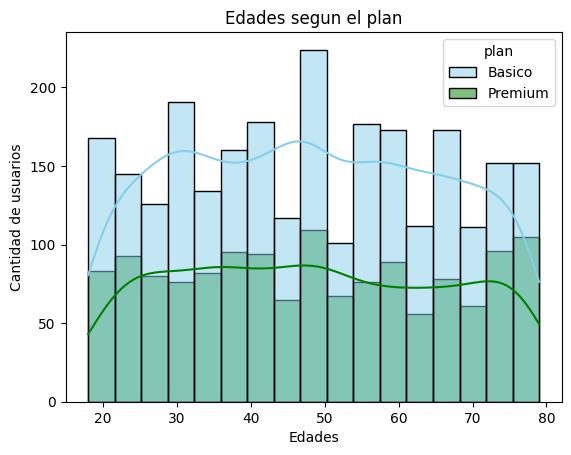

In [54]:
# Histograma para visualizar la edad (age)

sns.histplot(data= user_profile, x="age", hue="plan",palette=['skyblue','green'],kde=True)
plt.title("Edades segun el plan")
plt.xlabel("Edades")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights: 
- La columna de edad tiene una distribución simetrica donde no hay limites ni outliers y se puede observar que hay mayor cantidad de usuarios en el plan premium, aun mas en edades superiores. Se puede observar ademas un barra alta a la edad de 50 años equitativa para básico y premium

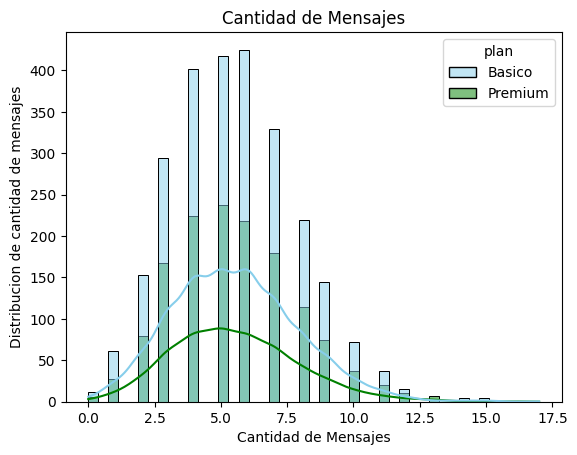

In [55]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data= user_profile, x="cant_mensajes", hue="plan",palette=['skyblue','green'],kde=True)
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Distribucion de cantidad de mensajes")
plt.title("Cantidad de Mensajes")
plt.show()


💡Insights: 
- La distribución de la cantidad de mensajes está ligeramente sesgada hacia la derecha, ya que la mayor concentración de datos se encuentra aproximadamente entre 3 y 8 mensajes, mientras que los valores más altos aparecen con menor frecuencia. Se observa que el plan Premium presenta una mayor concentración de registros en varios de los valores centrales de la distribución, especialmente alrededor de 4 a 6 mensajes. En general, ambos planes presentan un comportamiento similar en cuanto a la distribución de los mensajes, aunque el Premium muestra una mayor frecuencia en algunos de los rangos de mayor concentración.

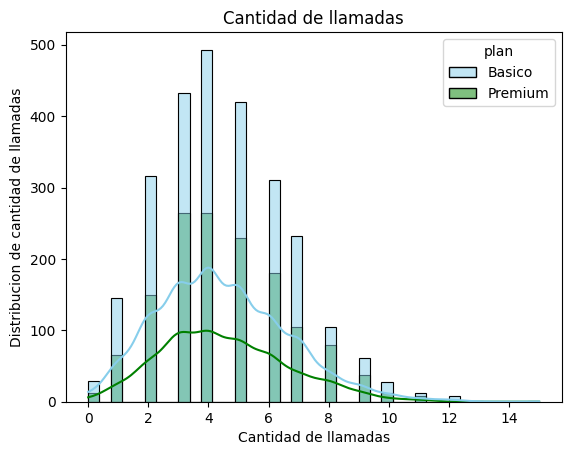

In [57]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x="cant_llamadas", hue="plan",palette=['skyblue','green'],kde=True)
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Distribucion de cantidad de llamadas")
plt.title("Cantidad de llamadas")
plt.show()

💡Insights: 
- La distribución de la cantidad de llamadas presenta un sesgo hacia la derecha, con mayor concentración entre 2 y 7 llamadas y un pico alrededor de 3 y 4. Al comparar los planes, se observa que Premium presenta una mayor frecuencia que Básico en varios de los valores centrales, mientras que las cantidades más altas de llamadas son menos frecuentes en ambos planes.

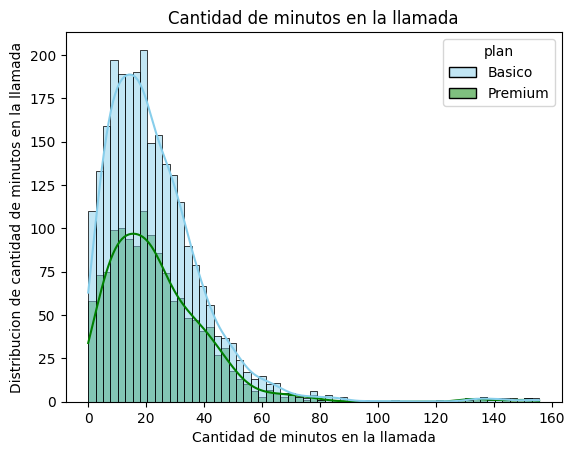

In [58]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x="cant_minutos_llamada", hue="plan",palette=['skyblue','green'],kde=True)
plt.xlabel("Cantidad de minutos en la llamada")
plt.ylabel("Distribucion de cantidad de minutos en la llamada")
plt.title("Cantidad de minutos en la llamada")
plt.show()

💡Insights: 
- Con respecto a la cantidad de minutos en la llamada se evidencia un sesgo a la derecha mas evidente, pero una simetria entre los planes básicos y premium, su mayor concentracion esta en la cantidad de 20 minutos en la llamada sin embargo, se observa cantidades de 140 minutos en el plan premium. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

age
AxesSubplot(0.125,0.11;0.775x0.77)



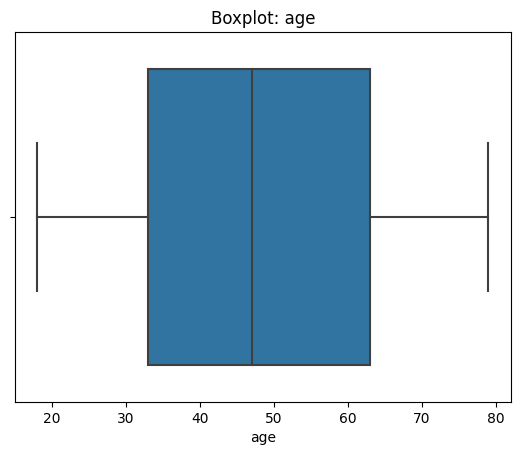

cant_mensajes
AxesSubplot(0.125,0.11;0.775x0.77)



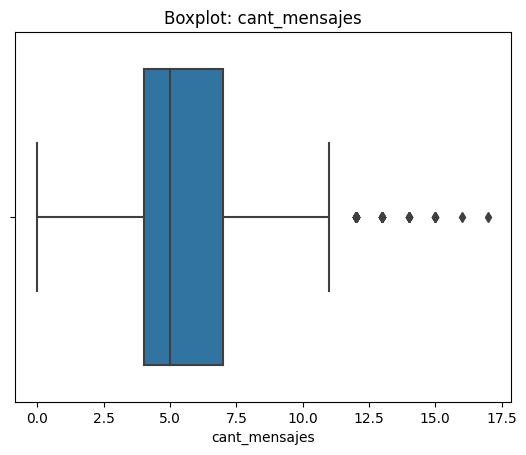

cant_llamadas
AxesSubplot(0.125,0.11;0.775x0.77)



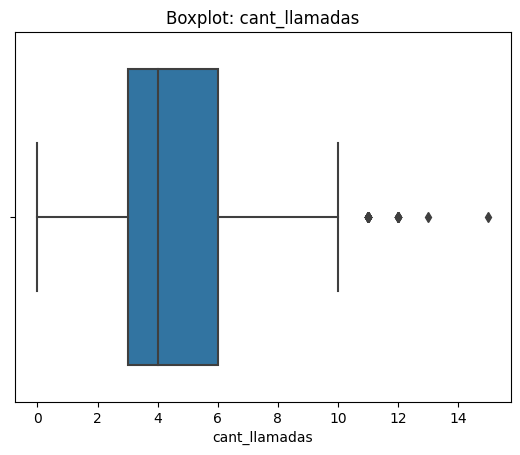

cant_minutos_llamada
AxesSubplot(0.125,0.11;0.775x0.77)



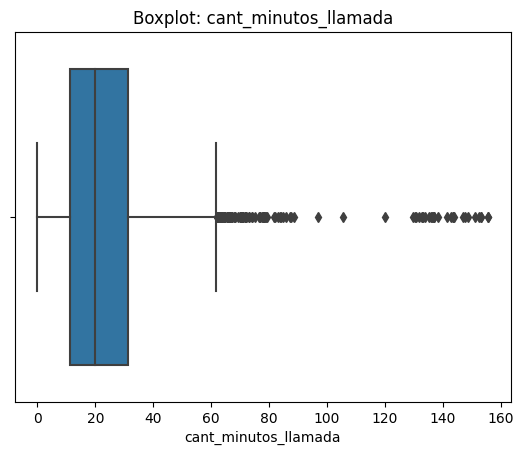

In [63]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    print(col)
    print(sns.boxplot(data=user_profile, x=col))
    print ()
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 

- Age: no presenta outliers
- cant_mensajes: presenta poca cantidad de outliers
- cant_llamadas: presenta poca cantidad de outliers
- cant_minutos_llamada: presenta gran cantidad de outliers


In [74]:
# Calcular límites con el método IQR
columnas_limites = ["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]
for col in columnas_limites:
    print (col)
    Q1=(user_profile[col].quantile(0.25))
    print("primer cuartil:",Q1)
    Q3=(user_profile[col].quantile(0.75))
    print("segundo cuartil:", Q3)
    IQR=(Q3-Q1)
    print ("IQR:", IQR)
    upper= Q3 + 1.5*IQR
    print("limite superior:", upper)
    print ()       



age
primer cuartil: 33.0
segundo cuartil: 63.0
IQR: 30.0
limite superior: 108.0

cant_mensajes
primer cuartil: 4.0
segundo cuartil: 7.0
IQR: 3.0
limite superior: 11.5

cant_llamadas
primer cuartil: 3.0
segundo cuartil: 6.0
IQR: 3.0
limite superior: 10.5

cant_minutos_llamada
primer cuartil: 11.12
segundo cuartil: 31.415
IQR: 20.295
limite superior: 61.8575



In [75]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes, cant_llamadas, cant_minutos_llamada: En estas tres columnas es razonable mantener los outliers puesto que representan unas cantidades de clientes premium que para la empresa de telecomunicaciones es algo favorable 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [83]:
# Crear columna grupo_uso
user_profile["grupo_uso"]= np.where ((user_profile["cant_mensajes"] <5) & (user_profile["cant_llamadas"] <5), "Bajo uso", np.where((user_profile["cant_mensajes"]<10) & (user_profile["cant_llamadas"]<10),"Uso medio","Alto uso"))


In [84]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [86]:
# Crear columna grupo_edad
user_profile["grupo_edad"]= np.where ((user_profile["age"] <30), "Joven", np.where((user_profile["age"]<60),"Adulto","Adulto Mayor"))

In [87]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

grupo_uso
AxesSubplot(0.125,0.11;0.775x0.77)


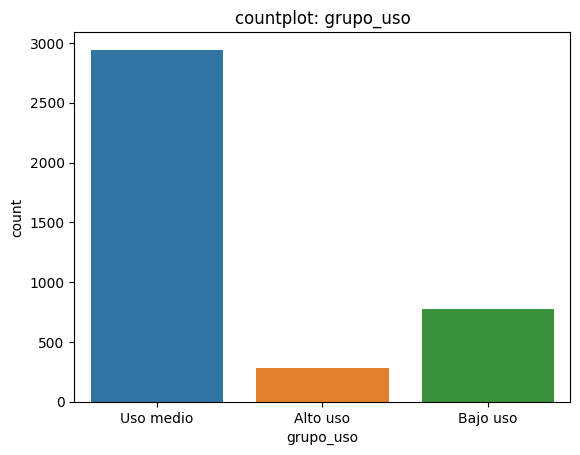

grupo_edad
AxesSubplot(0.125,0.11;0.775x0.77)


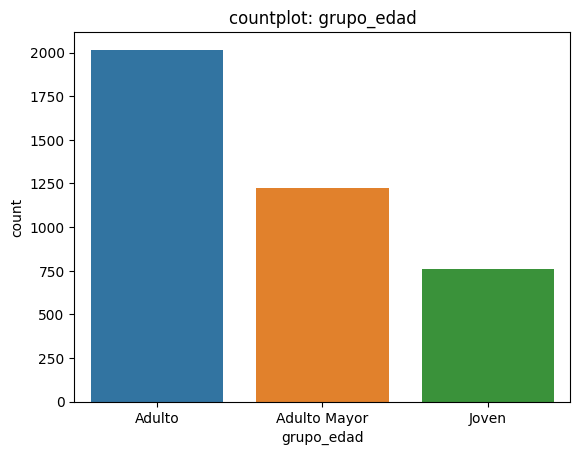

In [93]:
# Visualización de los segmentos por uso - # Visualización de los segmentos por edad

segmentacion_clientes=["grupo_uso","grupo_edad"]
for col in segmentacion_clientes:
    print (col)
    print (sns.countplot(data=user_profile, x=col))
    plt.title(f'countplot: {col}')
    plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-En el dataset users se encontraron valores faltantes principalmente en churn_date, con 3.534 registros (88,35%), y en city, con 469 registros (11,73%). También se detectaron 55 valores inválidos de edad (-999) y 96 registros con "?" en la columna city.
-En el dataset usage, duration presentó 22.076 valores nulos (55,19%) y length 17.896 (44,74%). Estos valores faltantes no necesariamente representan errores, ya que están relacionados con el tipo de uso: duration corresponde a llamadas y length al contenido de texto.
-También se identificaron 40 registros con el año 2026 en reg_date, aunque el periodo de investigación llega hasta 2024, por lo que estos registros deben revisarse o corregirse.

🔍 **Segmentos por Edad**
- Despues de la limpieza de la edad y el analisis desde los planes adquiridos, se puede considerar que los premium se observan aun mas efectivos en adultos mayores 
- Segun el grafico de segmentacion de clientes se puede concluir que existe una cantidad alta en adultos en la empresa de telecomunicaciones 


📊 **Segmentos por Nivel de Uso**
- a pesar que se cuenta con planes basicos y premium, se puede concluir que hay un uso medio de mensajes y llamadas y un bajo nivel con respecto a bajo uso de estos
- Los outliers de mensajes, llamadas y minutos se mantienen porque pueden representar clientes Premium o de alto consumo, que son especialmente relevantes para una empresa de telecomunicaciones.


➡️ Esto sugiere que Los clientes con alto consumo de llamadas, mensajes o minutos parecen ser segmentos importantes para ConnectaTel porque utilizan los servicios con mayor frecuencia y pueden representar una mayor oportunidad de ingresos.
Los clientes con consumo elevado de minutos de llamadas merecen especial atención, ya que esta variable presenta una cantidad considerable de valores extremos que pueden corresponder a usuarios intensivos.

Estos valores extremos no deben eliminarse automáticamente, porque pueden corresponder a clientes reales con un nivel de consumo elevado.
Para el negocio, estos patrones pueden indicar la existencia de usuarios que requieren mayores cantidades de minutos, llamadas o mensajes y que podrían estar interesados en planes diseñados para consumos altos.


💡 **Recomendaciones**
-Mantener una oferta diferenciada de planes: conservar planes para usuarios de bajo consumo y desarrollar alternativas para clientes con consumo medio y alto.
-Crear o fortalecer un plan para usuarios intensivos, con una mayor cantidad de minutos y beneficios adicionales en llamadas y mensajes.
-Analizar planes según el tipo de consumo, diferenciando clientes cuyo uso se concentra en llamadas de aquellos que utilizan principalmente mensajes.
-Revisar periódicamente los patrones de consumo para identificar cambios en los segmentos y ajustar las características de los planes.
-Conservar los outliers reales en el análisis, ya que pueden representar clientes de alto valor y no necesariamente errores en los datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`